# Análise de Sentimento aplicadas à sentenças financeiras em PT-BR

fonte: https://www.kaggle.com/datasets/mateuspicanco/financial-phrase-bank-portuguese-translation/data

In [1]:
# Carregando pacotes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk import ngrams
from nltk.tokenize import word_tokenize
from collections import Counter
import spacy
nlp = spacy.load('pt_core_news_sm')
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\luans\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Carregando dados

In [ ]:
import zipfile as zip

with zip.ZipFile('dados/financial_phrase_bank_pt_br.csv.zip', 'r') as zObject:
    zObject.extractall(path='dados/')

# Carregando os dados
df = pd.read_csv('dados/financial_phrase_bank_pt_br.csv')

df.head()

,y,text,text_pt
0,neutral,Technopolis plans to develop in stages an area...,A Technopolis planeja desenvolver em etapas um...
1,negative,The international electronic industry company ...,"A Elcoteq, empresa internacional da indústria ..."
2,positive,With the new production plant the company woul...,Com a nova planta de produção a empresa aument...
3,positive,According to the company 's updated strategy f...,De acordo com a estratégia atualizada da empre...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,FINANCIAMENTO DO CRESCIMENTO DA ASPOCOMP A Asp...


In [3]:
df.rename(columns={'y': 'sentiment'}, inplace=True)
df['sentiment'].value_counts()

sentiment
neutral     2878
positive    1363
negative     604
Name: count, dtype: int64

## Processamento de Texto

In [6]:
import string

stop_words = set(stopwords.words('portuguese'))
stop_words.update(['em', 'um', 'uma', 'a', 'as', 'o', 'os', 'de', 'do', 'da', 'dos', 'das', 'e', 'que', 'com', 'para', 'por', 'no', 'na', 'nos', 'nas'])

df['text_pt_clean'] = df['text_pt'].str.lower() 
df['text_pt_clean'] = df['text_pt_clean'].str.translate(str.maketrans('', '', string.punctuation))
df['text_pt_clean'] = df['text_pt_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

df.head()

,sentiment,text,text_pt,text_pt_clean
0,neutral,Technopolis plans to develop in stages an area...,A Technopolis planeja desenvolver em etapas um...,technopolis planeja desenvolver etapas área in...
1,negative,The international electronic industry company ...,"A Elcoteq, empresa internacional da indústria ...",elcoteq empresa internacional indústria eletrô...
2,positive,With the new production plant the company woul...,Com a nova planta de produção a empresa aument...,nova planta produção empresa aumentaria capaci...
3,positive,According to the company 's updated strategy f...,De acordo com a estratégia atualizada da empre...,acordo estratégia atualizada empresa anos 2009...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,FINANCIAMENTO DO CRESCIMENTO DA ASPOCOMP A Asp...,financiamento crescimento aspocomp aspocomp pe...


In [7]:
# Lemmatization

lemma_docs = nlp.pipe(df['text_pt_clean'])

df['text_pt_lemma'] = [' '.join([token.lemma_ for token in doc]) for doc in lemma_docs]

df.head()

,sentiment,text,text_pt,text_pt_clean,text_pt_lemma
0,neutral,Technopolis plans to develop in stages an area...,A Technopolis planeja desenvolver em etapas um...,technopolis planeja desenvolver etapas área in...,technopoli planejar desenvolver etapa área inf...
1,negative,The international electronic industry company ...,"A Elcoteq, empresa internacional da indústria ...",elcoteq empresa internacional indústria eletrô...,elcoteq empresa internacional indústria eletrô...
2,positive,With the new production plant the company woul...,Com a nova planta de produção a empresa aument...,nova planta produção empresa aumentaria capaci...,novo planto produção empreso aumentar capacida...
3,positive,According to the company 's updated strategy f...,De acordo com a estratégia atualizada da empre...,acordo estratégia atualizada empresa anos 2009...,Acordo estratégia atualizado empresa ano 20092...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,FINANCIAMENTO DO CRESCIMENTO DA ASPOCOMP A Asp...,financiamento crescimento aspocomp aspocomp pe...,financiamento crescimento aspocomp aspocomp pe...


In [9]:
# n-grams

nltk.download('punkt_tab')

def get_ngrams(column, n):
    text = ' '.join(word for word in column.str.lower() if word not in stopwords.words('portuguese'))
    tokens = word_tokenize(text, language='portuguese')
    return list(ngrams(tokens, n))

bigrams = get_ngrams(df['text_pt_lemma'], 2)

print(bigrams[:10])

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\luans\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


[('technopoli', 'planejar'), ('planejar', 'desenvolver'), ('desenvolver', 'etapa'), ('etapa', 'área'), ('área', 'inferior'), ('inferior', '100'), ('100', 'mil'), ('mil', 'metros'), ('metros', 'quadrados'), ('quadrados', 'hospedar')]


In [13]:
from collections import Counter

bigrams = get_ngrams(df['text_pt_clean'], 2)
trigrams = get_ngrams(df['text_pt_clean'], 3)

freq_bigram = Counter(bigrams)
freq_trigram = Counter(trigrams)

print('Bi-grans mais comuns:')
for n, freq in enumerate(freq_bigram.most_common(5)):
    print(f'Bi-gram {n+1}: {freq[0]} - Frequência: {freq[1]}')

print('=' * 20)

print('Tri-grans mais comuns:')
for n, freq in enumerate(freq_trigram.most_common(5)):
    print(f'Tri-gram {n+1}: {freq[0]} - Frequência: {freq[1]}')

Bi-grans mais comuns:
Bi-gram 1: ('milhões', 'euros') - Frequência: 399
Bi-gram 2: ('vendas', 'líquidas') - Frequência: 241
Bi-gram 3: ('lucro', 'operacional') - Frequência: 197
Bi-gram 4: ('milhões', 'eur') - Frequência: 114
Bi-gram 5: ('euros', 'us') - Frequência: 112
Tri-grans mais comuns:
Tri-gram 1: ('milhões', 'euros', 'us') - Frequência: 92
Tri-gram 2: ('milhões', 'período', 'correspondente') - Frequência: 58
Tri-gram 3: ('lucro', 'antes', 'impostos') - Frequência: 37
Tri-gram 4: ('primeiros', 'nove', 'meses') - Frequência: 30
Tri-gram 5: ('lucro', 'operacional', 'eur') - Frequência: 28


In [14]:
unigram_pos = get_ngrams(df[df['sentiment'] == 'positive']['text_pt_clean'], 1)
unigram_neg = get_ngrams(df[df['sentiment'] == 'negative']['text_pt_clean'], 1)
unigram_neu = get_ngrams(df[df['sentiment'] == 'neutral']['text_pt_clean'], 1)

freq_unigram_pos = Counter(unigram_pos)
freq_unigram_neg = Counter(unigram_neg)
freq_unigram_neu = Counter(unigram_neu)

print('Palavras mais comuns - Positivo:')
for n, freq in enumerate(freq_unigram_pos.most_common(5)):
    print(f'Unigrama {n+1}: {freq[0]} - Frequência: {freq[1]}')

print('=' * 20)

print('Palavras mais comuns - Negativo:')
for n, freq in enumerate(freq_unigram_neg.most_common(5)):
    print(f'Unigrama {n+1}: {freq[0]} - Frequência: {freq[1]}')

print('=' * 20)

print('Palavras mais comuns - Neutro:')
for n, freq in enumerate(freq_unigram_neu.most_common(5)):
    print(f'Unigrama {n+1}: {freq[0]} - Frequência: {freq[1]}')

Palavras mais comuns - Positivo:
Unigrama 1: ('milhões',) - Frequência: 692
Unigrama 2: ('eur',) - Frequência: 366
Unigrama 3: ('empresa',) - Frequência: 236
Unigrama 4: ('disse',) - Frequência: 235
Unigrama 5: ('euros',) - Frequência: 218
Palavras mais comuns - Negativo:
Unigrama 1: ('milhões',) - Frequência: 451
Unigrama 2: ('eur',) - Frequência: 293
Unigrama 3: ('lucro',) - Frequência: 163
Unigrama 4: ('euros',) - Frequência: 103
Unigrama 5: ('vendas',) - Frequência: 98
Palavras mais comuns - Neutro:
Unigrama 1: ('empresa',) - Frequência: 493
Unigrama 2: ('milhões',) - Frequência: 480
Unigrama 3: ('disse',) - Frequência: 240
Unigrama 4: ('ações',) - Frequência: 229
Unigrama 5: ('finlândia',) - Frequência: 216


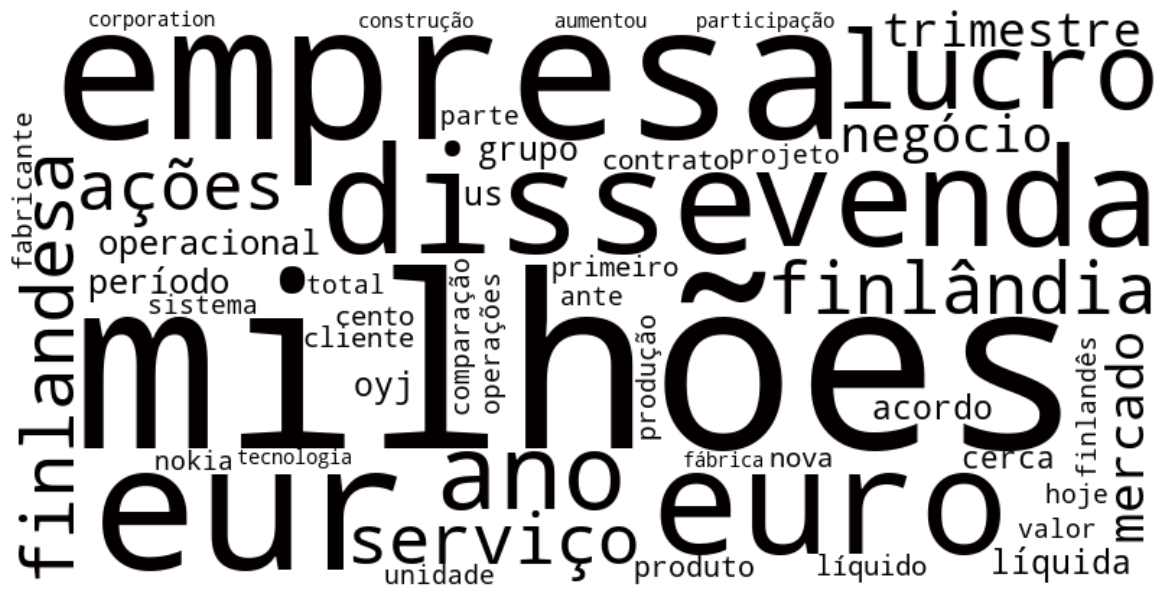

In [12]:
from wordcloud import WordCloud

def black_color_func(word, font_size, position,orientation,random_state=None, **kwargs):
    return("hsl(0,100%, 1%)")

text = ' '.join(word for word in df['text_pt_clean'])
wordcloud = WordCloud(max_words=50, background_color='white', width=800, height=400, collocations=False).generate(text)
wordcloud.recolor(color_func=black_color_func)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

wordcloud.to_file('imagens/financial_phrases_ptbr_wordcloud.png')

## Implementação do modelo

In [4]:
# Seed para reprodutibilidade
np.random.seed(42)

### Realizando testes nos dados crus

In [16]:
# dados crus (raw data)

x = df['text_pt']
y = df['sentiment']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

model = make_pipeline(CountVectorizer(), MultinomialNB())
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.75      0.37      0.50       121
     neutral       0.76      0.88      0.81       576
    positive       0.61      0.54      0.57       272

    accuracy                           0.72       969
   macro avg       0.71      0.60      0.63       969
weighted avg       0.71      0.72      0.71       969



In [17]:
param_grid = {
    'countvectorizer__max_features': [1000, 2000, 5000],
    'countvectorizer__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'multinomialnb__alpha': [0.01, 0.1, 1.0]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(x_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

y_pred_grid = grid_search.predict(x_test)

print(classification_report(y_test, y_pred_grid))

Best parameters: {'countvectorizer__max_features': 5000, 'countvectorizer__ngram_range': (1, 1), 'multinomialnb__alpha': 1.0}
Best CV score: 0.7091
              precision    recall  f1-score   support

    negative       0.57      0.50      0.53       121
     neutral       0.77      0.85      0.81       576
    positive       0.64      0.53      0.58       272

    accuracy                           0.72       969
   macro avg       0.66      0.62      0.64       969
weighted avg       0.71      0.72      0.71       969



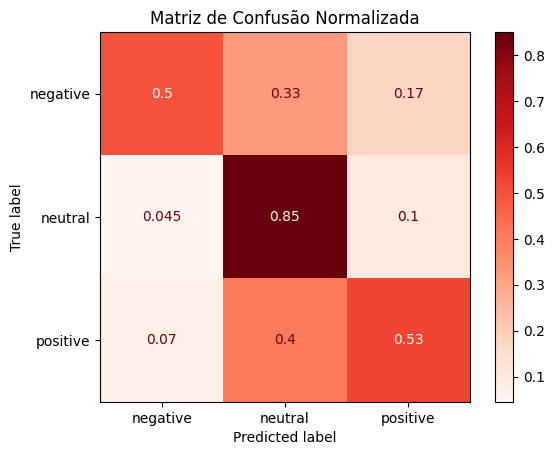

In [18]:
disp = ConfusionMatrixDisplay.from_estimator(
    grid_search,
    x_test,
    y_test,
    display_labels=grid_search.classes_,
    cmap=plt.cm.Reds,
    normalize='true'
)

disp.ax_.set_title("Matriz de Confusão Normalizada")

plt.show()

### Testes com os dados limpos

In [19]:
# dados limpos

x = df['text_pt_clean']
y = df['sentiment']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

model = make_pipeline(CountVectorizer(), MultinomialNB())
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.72      0.45      0.56       121
     neutral       0.75      0.86      0.81       576
    positive       0.59      0.51      0.55       272

    accuracy                           0.71       969
   macro avg       0.69      0.61      0.64       969
weighted avg       0.71      0.71      0.70       969



In [20]:
param_grid = {
    'countvectorizer__max_features': [1000, 2000, 5000],
    'countvectorizer__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'multinomialnb__alpha': [0.01, 0.1, 1.0]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(x_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

y_pred_grid = grid_search.predict(x_test)

print(classification_report(y_test, y_pred_grid))

Best parameters: {'countvectorizer__max_features': 5000, 'countvectorizer__ngram_range': (1, 1), 'multinomialnb__alpha': 1.0}
Best CV score: 0.7093
              precision    recall  f1-score   support

    negative       0.57      0.56      0.56       121
     neutral       0.77      0.85      0.81       576
    positive       0.63      0.50      0.56       272

    accuracy                           0.72       969
   macro avg       0.66      0.64      0.64       969
weighted avg       0.71      0.72      0.71       969



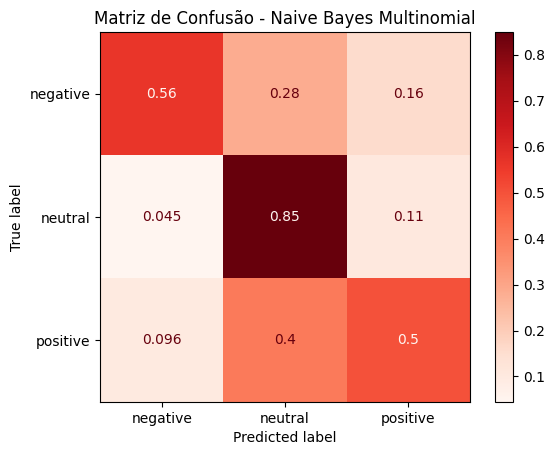

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(
    grid_search,
    x_test,
    y_test,
    display_labels=grid_search.classes_,
    cmap=plt.cm.Reds,
    normalize='true'
)

disp.ax_.set_title("Matriz de Confusão - Naive Bayes Multinomial")

plt.show()

In [22]:
# salvando modelo
import joblib
joblib.dump(grid_search.best_estimator_, 'modelos/naive_bayes_sentiment_analysis_ptbr.pkl')

# salvando base de dados
df.to_csv('dados/financial_phrase_bank_pt_br_new.csv', sep=";", decimal=",", index=False, encoding="utf-8-sig")

## CountVectorizer vs TfidfVectorizer

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

df = pd.read_csv('dados/financial_phrase_bank_pt_br_new.csv', sep=";", decimal=",", encoding="utf-8-sig")
df['text_pt_clean'] = df['text_pt_clean'].fillna('')

x = df['text_pt_clean']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

param_grid = {
    'tfidf__max_features': [3000, 5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [1, 2, 5],
    'tfidf__sublinear_tf': [True, False],
    'clf__alpha': [0.1, 0.5, 1.0]  # suavização do Naive Bayes
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',   # bom para classes desbalanceadas (pos/neg/neutro)
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor F1 (macro):", grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Melhores parâmetros: {'clf__alpha': 0.1, 'tfidf__max_features': 3000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': False}
Melhor F1 (macro): 0.6352577388283245


In [8]:
import joblib

joblib.dump(grid.best_estimator_, 'modelos/naive_bayes_sentiment_analysis_ptbr_tfidf.pkl')

['modelos/naive_bayes_sentiment_analysis_ptbr_tfidf.pkl']

In [9]:
import joblib

# CountVectorizer + MultinomialNB
model_count = joblib.load('modelos/naive_bayes_sentiment_analysis_ptbr.pkl')

y_pred_count = model_count.predict(X_test)

# TfidfVectorizer + MultinomialNB
model_tfidf = joblib.load('modelos/naive_bayes_sentiment_analysis_ptbr_tfidf.pkl')
y_pred_tfidf = model_tfidf.predict(X_test)

# Calcular métricas para ambos
print("=" * 70)
print("COMPARAÇÃO: CountVectorizer vs TfidfVectorizer")
print("=" * 70)

for name, model, y_pred in [("CountVectorizer", model_count, y_pred_count), 
                             ("TfidfVectorizer", model_tfidf, y_pred_tfidf)]:
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:2.2%}")
    print(f"  Precision: {prec:2.2%}")
    print(f"  Recall:    {rec:2.2%}")
    print(f"  F1 Score:  {f1:2.2%}")

print("=" * 70)

COMPARAÇÃO: CountVectorizer vs TfidfVectorizer

CountVectorizer:
  Accuracy:  71.52%
  Precision: 70.67%
  Recall:    71.52%
  F1 Score:  70.78%

TfidfVectorizer:
  Accuracy:  72.34%
  Precision: 71.06%
  Recall:    72.34%
  F1 Score:  70.44%


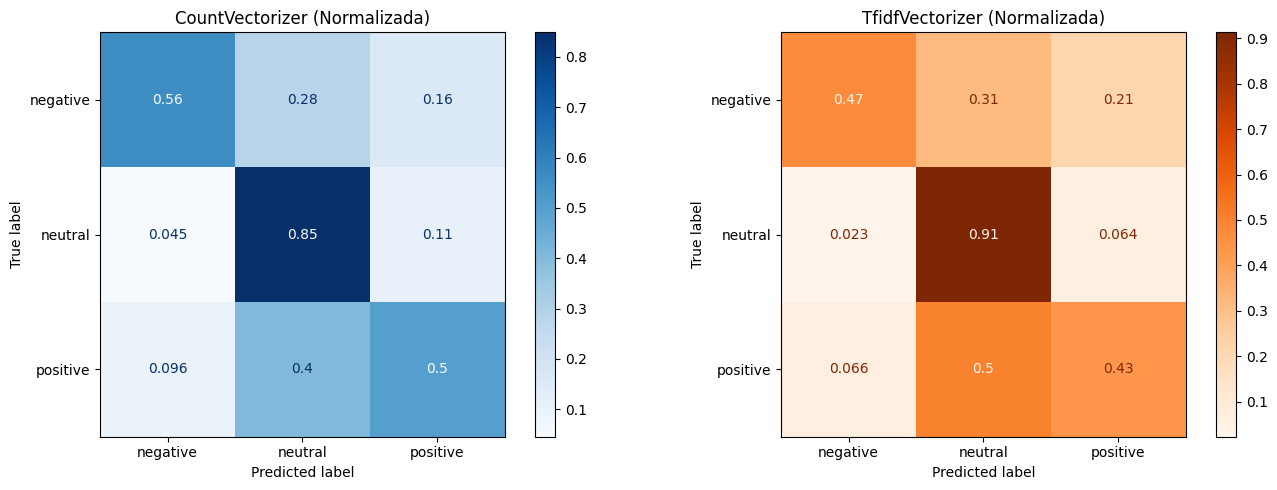

In [10]:
# Visualizar matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CountVectorizer
disp1 = ConfusionMatrixDisplay.from_estimator(
    model_count, X_test, y_test,
    display_labels=['negative', 'neutral', 'positive'],
    cmap=plt.cm.Blues,
    normalize='true',
    ax=axes[0]
)
disp1.ax_.set_title("CountVectorizer (Normalizada)")

# TfidfVectorizer
disp2 = ConfusionMatrixDisplay.from_estimator(
    model_tfidf, X_test, y_test,
    display_labels=['negative', 'neutral', 'positive'],
    cmap=plt.cm.Oranges,
    normalize='true',
    ax=axes[1]
)
disp2.ax_.set_title("TfidfVectorizer (Normalizada)")

plt.tight_layout()
plt.show()